# Problema 2
Laboratorio 7 (parte de código)

Autores:
* Ricardo Morales Contreras - 22289
* José Ángel Morales - 22689
* Javier Ovalle Chiquin - 22103

Acá importamos las librerías necesarias

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')

Acá creamos los contadores para la ejecucion, los creamos mediante funciones

In [2]:
MAX_TIME_SEC = 60.0  # Límite de 60 segundos por corrida

def function_A(n):
    counter = 0
    start_time = time.perf_counter()

    # Rango de n/2 a n inclusive
    for i in range(n // 2, n + 1):
        j = 1
        while j + n // 2 <= n:
            k = 1
            while k <= n:
                counter += 1
                k *= 2

                # Check de seguridad para N grandes
                if counter % 1000000 == 0:
                    if time.perf_counter() - start_time > MAX_TIME_SEC:
                        return counter, True # Timeout alcanzado
            j += 1
    return counter, False

def function_B(n):
    counter = 0
    start_time = time.perf_counter()

    if n <= 1:
        return counter, False

    for i in range(1, n + 1):
        for j in range(1, n + 1):
            counter += 1
            break # El ciclo interno se interrumpe inmediatamente

        if i % 100000 == 0:
            if time.perf_counter() - start_time > MAX_TIME_SEC:
                return counter, True

    return counter, False

def function_C(n):
    counter = 0
    start_time = time.perf_counter()

    for i in range(1, (n // 3) + 1):
        j = 1
        while j <= n:
            counter += 1
            j += 4

            if counter % 1000000 == 0:
                if time.perf_counter() - start_time > MAX_TIME_SEC:
                    return counter, True
    return counter, False

Definimos los tamaños de entrada mediuante un vector, esto para dar paso a la ejecución

In [3]:
# Tamaños de entrada definidos en las instrucciones
tamanos_entrada = [1, 10, 100, 1000, 10000, 100000, 1000000]

resultados = {
    'A': {'tiempos': [], 'operaciones': [], 'timeout': []},
    'B': {'tiempos': [], 'operaciones': [], 'timeout': []},
    'C': {'tiempos': [], 'operaciones': [], 'timeout': []}
}

funciones = {'A': function_A, 'B': function_B, 'C': function_C}

print("Iniciando Profiling... (Esto puede tomar un par de minutos)")

for nombre, func in funciones.items():
    print(f"\nEvaluando Algoritmo {nombre}...")
    for n in tamanos_entrada:
        t_inicio = time.perf_counter()
        ops, timeout = func(n)
        t_fin = time.perf_counter()

        tiempo_real = t_fin - t_inicio

        resultados[nombre]['tiempos'].append(tiempo_real)
        resultados[nombre]['operaciones'].append(ops)
        resultados[nombre]['timeout'].append(timeout)

        estado = "[TIMEOUT]" if timeout else "[COMPLETADO]"
        print(f"  N = {n:<10} | Tiempo: {tiempo_real:>8.4f}s | Operaciones: {ops:<15} {estado}")

        if timeout:
            print(f"  -> {nombre} abortado en N={n} por exceder los {MAX_TIME_SEC} segundos.")
            # Rellenar con NaN las entradas restantes para no dejar arrays desiguales
            for n_restante in tamanos_entrada[tamanos_entrada.index(n)+1:]:
                resultados[nombre]['tiempos'].append(np.nan)
                resultados[nombre]['operaciones'].append(np.nan)
                resultados[nombre]['timeout'].append(True)
            break

print("\nProfiling finalizado.")

Iniciando Profiling... (Esto puede tomar un par de minutos)

Evaluando Algoritmo A...
  N = 1          | Tiempo:   0.0000s | Operaciones: 2               [COMPLETADO]
  N = 10         | Tiempo:   0.0000s | Operaciones: 120             [COMPLETADO]
  N = 100        | Tiempo:   0.0012s | Operaciones: 17850           [COMPLETADO]
  N = 1000       | Tiempo:   0.1881s | Operaciones: 2505000         [COMPLETADO]
  N = 10000      | Tiempo:  28.5393s | Operaciones: 350070000       [COMPLETADO]
  N = 100000     | Tiempo:  60.0224s | Operaciones: 873000000       [TIMEOUT]
  -> A abortado en N=100000 por exceder los 60.0 segundos.

Evaluando Algoritmo B...
  N = 1          | Tiempo:   0.0000s | Operaciones: 0               [COMPLETADO]
  N = 10         | Tiempo:   0.0000s | Operaciones: 10              [COMPLETADO]
  N = 100        | Tiempo:   0.0000s | Operaciones: 100             [COMPLETADO]
  N = 1000       | Tiempo:   0.0001s | Operaciones: 1000            [COMPLETADO]
  N = 10000      | Tie

In [4]:
# Estructuración de los datos en un DataFrame multicapa de Pandas
columnas = pd.MultiIndex.from_product(
    [['Algoritmo A', 'Algoritmo B', 'Algoritmo C'], ['Tiempo (s)', 'Operaciones']],
    names=['Algoritmo', 'Metrica']
)

df_resultados = pd.DataFrame(index=tamanos_entrada, columns=columnas)
df_resultados.index.name = 'Tamano Entrada (N)'

for nombre in ['A', 'B', 'C']:
    algo_key = f'Algoritmo {nombre}'
    df_resultados[(algo_key, 'Tiempo (s)')] = resultados[nombre]['tiempos']
    df_resultados[(algo_key, 'Operaciones')] = resultados[nombre]['operaciones']

# Rellenar los valores vacíos (causados por los Timeouts) con texto descriptivo
df_tabla_visual = df_resultados.fillna('> 60.00s (Timeout)')

print("\n=== TABLA DE RESULTADOS DE PROFILING ===")
display(df_tabla_visual)


=== TABLA DE RESULTADOS DE PROFILING ===


Algoritmo                  Algoritmo A                     Algoritmo B  \
Metrica                     Tiempo (s)         Operaciones  Tiempo (s)   
Tamano Entrada (N)                                                       
1                             0.000006                 2.0    0.000001   
10                             0.00001               120.0    0.000006   
100                           0.001216             17850.0    0.000012   
1000                          0.188099           2505000.0    0.000136   
10000                        28.539323         350070000.0    0.001375   
100000                       60.022395         873000000.0    0.014660   
1000000             > 60.00s (Timeout)  > 60.00s (Timeout)    0.146937   

Algoritmo                      Algoritmo C              
Metrica            Operaciones  Tiempo (s) Operaciones  
Tamano Entrada (N)                                      
1                            0    0.000004           0  
10                          10    0.000003           9  
100                        100    0.000049         825  
1000                      1000    0.005219       83250  
10000                    10000    0.522186     8332500  
100000                  100000   56.080096   833325000  
1000000                1000000   60.042710   920000000

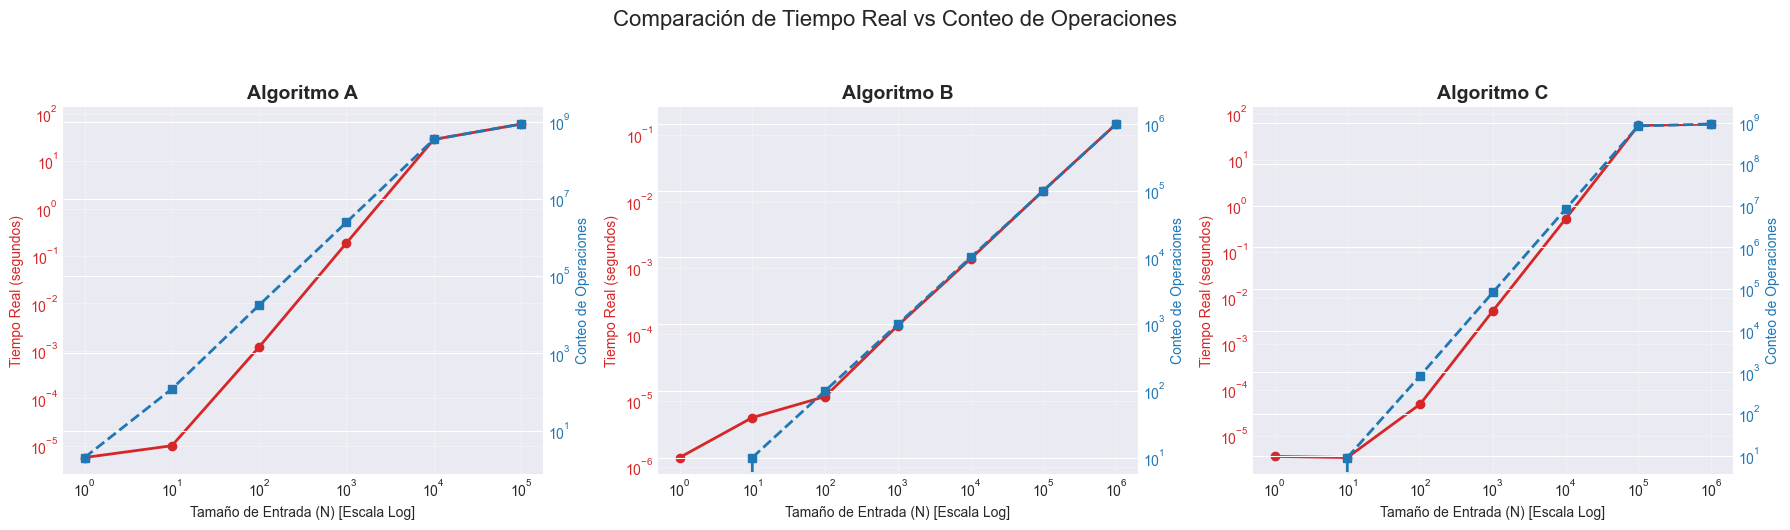

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación de Tiempo Real vs Conteo de Operaciones', fontsize=16, y=1.05)

n_sizes_arr = np.array(tamanos_entrada)

for i, nombre in enumerate(['A', 'B', 'C']):
    ax1 = axes[i]

    # Extraer datos ignorando los NaN del timeout
    tiempos = np.array(resultados[nombre]['tiempos'])
    ops = np.array(resultados[nombre]['operaciones'])

    mask = ~np.isnan(tiempos)
    valid_n = n_sizes_arr[mask]
    valid_tiempos = tiempos[mask]
    valid_ops = ops[mask]

    # Eje Y Primario: Tiempo
    color1 = 'tab:red'
    ax1.set_xlabel('Tamaño de Entrada (N) [Escala Log]')
    ax1.set_ylabel('Tiempo Real (segundos)', color=color1)
    ax1.plot(valid_n, valid_tiempos, color=color1, marker='o', linewidth=2, label='Tiempo')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_xscale('log')

    if np.max(valid_tiempos) > 0:
        ax1.set_yscale('log')

    # Eje Y Secundario: Operaciones
    ax2 = ax1.twinx()
    color2 = 'tab:blue'
    ax2.set_ylabel('Conteo de Operaciones', color=color2)
    ax2.plot(valid_n, valid_ops, color=color2, marker='s', linestyle='--', linewidth=2, label='Ops')
    ax2.tick_params(axis='y', labelcolor=color2)
    if np.max(valid_ops) > 0:
        ax2.set_yscale('log')

    ax1.set_title(f'Algoritmo {nombre}', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()